In [1]:
import pandas as pd
import numpy as np
import pandas_ta as ta
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import joblib

In [2]:
df = pd.read_csv('USDJPY_M15_20241030.csv', parse_dates=["Date"], index_col=0)

In [3]:
# target calculation
df['returns'] = df['Close'].pct_change()
df['target'] = (df['returns'] > 0).astype(int)
df['s_returns'] = df['returns']
df['cumulative_buy_and_hold_returns'] = df["returns"].cumsum().apply(np.exp)

# Shift price and returns to prevent lookahead bias
df['Close'] = df['Close'].shift(1)
df['Open'] = df['Open'].shift(1)
df['High'] = df['High'].shift(1)
df['Low'] = df['Low'].shift(1)
df['returns'] = df['returns'].shift(1)
df['volatility'] = df['returns'].rolling(window=8).std()
df['returns_div_volatility'] = df['returns'] / df['volatility'].replace(0, np.nan)
df['returns_inv'] = 1 / df['returns'].replace(0, np.nan)
df['volatility_inv'] = 1 / df['volatility'].replace(0, np.nan)
df[['stoch_k', 'stoch_d']] = ta.stoch(df['High'], df['Low'], df['Close'], 13, 3, 3)
df['stoch'] = np.where(
    (df['stoch_k'] > df['stoch_d']) & (df['stoch_k'] <= 20), 1,
    np.where((df['stoch_k'] < df['stoch_d']) & (df['stoch_k'] >= 80), -1, 0)
)
df.dropna(inplace=True)

#HMM
feature_matrix = df[['returns', 'volatility']]
scaler_hmm = StandardScaler()
feature_matrix_scaled = scaler_hmm.fit_transform(feature_matrix)
hmm_model = GaussianHMM(n_components = 5, covariance_type="full", n_iter = 100 , random_state=42)
hmm_model.fit(feature_matrix_scaled)
df['hmm_regime'] = hmm_model.predict(feature_matrix_scaled)
probabilities = hmm_model.predict_proba(feature_matrix_scaled)
df['hmm_prob_0'] = probabilities[:, 0]
df['hmm_prob_1'] = probabilities[:, 1]
df['hmm_prob_2'] = probabilities[:, 2]
df['hmm_prob_3'] = probabilities[:, 3]
df['hmm_prob_4'] = probabilities[:, 4]

# Final clean up
df.replace([np.inf, -np.inf], 0, inplace=True)
df.dropna(inplace=True)

In [4]:
# features
features = df.drop(columns=['target', 's_returns', 'cumulative_buy_and_hold_returns', 'Close', 'Open', 'High', 'Low', 'stoch_k', 'stoch_d','stoch']).columns

# Define features and target
X = df[features]
y = df["target"]

# Apply StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Convert the scaled NumPy array back to a DataFrame
X = pd.DataFrame(X, columns=features)

In [5]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_clf = RandomForestClassifier(n_estimators=500,
                                max_depth=5,
                                class_weight = 'balanced',
                                random_state=42)


model = rf_clf

# Train the model on the training set
model.fit(X_train, y_train)

# Predict and calculate accuracy for training and testing sets
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

accuracy_train = accuracy_score(y_train, y_pred_train) * 100
accuracy_test = accuracy_score(y_test, y_pred_test) * 100

# Print train and test accuracy
print(f"Train Accuracy: {accuracy_train:.2f}")
print(f"Test Accuracy: {accuracy_test:.2f}")

# Predict on the entire dataset
df['pred'] = model.predict(X)
total_accuracy = accuracy_score(df.target, df.pred) * 100
print(f"Total Accuracy: {total_accuracy:.2f}")

# Get predicted probabilities for each class
probs = model.predict_proba(X)

# Add these probabilities to the dataframe
df['prob_class_-1'] = probs[:, 0]
df['prob_class_1'] = probs[:, 1]
df['prob'] = np.where(df['prob_class_1'] > df['prob_class_-1'], df['prob_class_1'], df['prob_class_-1'])

Train Accuracy: 52.98
Test Accuracy: 50.98
Total Accuracy: 52.58


In [6]:
objects_to_save = {
    'clf': model,
    'hmm': hmm_model,
    'scaler': scaler,
    'scaler_hmm': scaler_hmm}
joblib.dump(objects_to_save, 'U_J_20241030.joblib')

['U_J_20241030.joblib']

# Filter and Evaluations

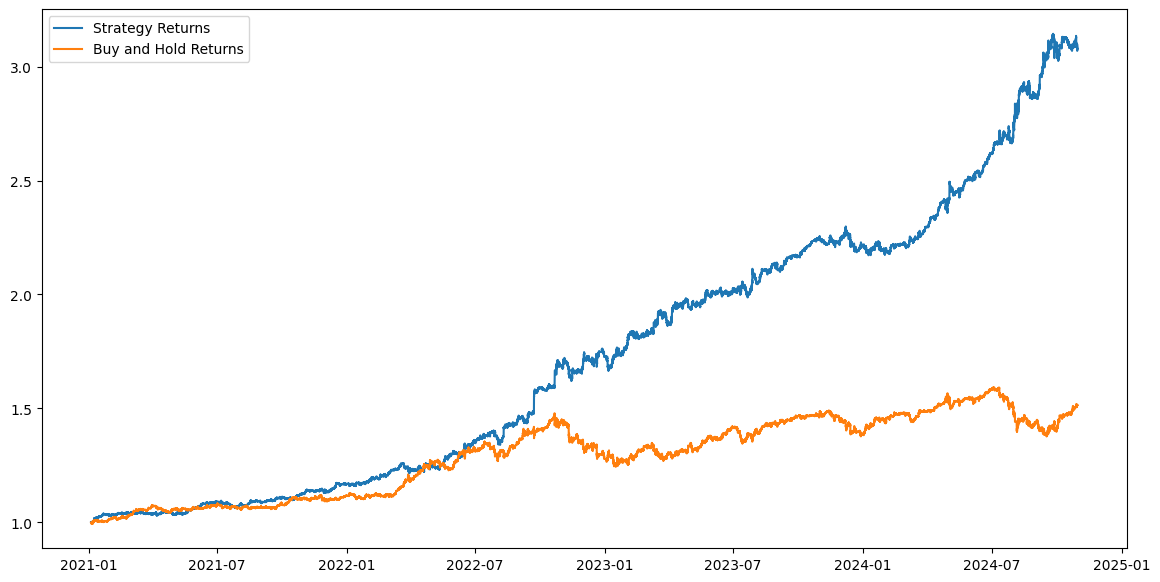

In [7]:
# strategy
df['pred'] = df['pred'].map({0: -1, 1: 1})
df['strategy'] = df['pred'] * df['s_returns']
df['cumulative_strategy_returns'] = df["strategy"].cumsum().apply(np.exp)

# plot
plt.figure(figsize=(14,7))
plt.plot(df['cumulative_strategy_returns'], label=f'Strategy Returns')
plt.plot(df['cumulative_buy_and_hold_returns'], label=f'Buy and Hold Returns')
plt.legend()
plt.show()

In [8]:
# Actual returns associated with each trade
annualized_factor = 24960  # The number of 15-minute bars in a year
annualized_sreturn = np.mean(df['strategy']) * annualized_factor
print(f"Annualized Strategy Return: {annualized_sreturn:.2f}")

# Sharpe Ratio
risk_free_rate = 0  # Assuming risk-free rate is 0 for simplicity
mean_return = np.mean(df['strategy']) * annualized_factor
std_return = np.std(df['strategy']) * np.sqrt(annualized_factor)
sharpe_ratio = (mean_return - risk_free_rate) / std_return
print(f"Annualized Sharpe Ratio: {sharpe_ratio:.2f}")


# Maximum Drawdown
def max_drawdown(strategy_returns):
    cumulative = np.cumsum(strategy_returns)
    drawdown = cumulative - np.maximum.accumulate(cumulative)
    return np.min(drawdown)

max_dd = max_drawdown(df['strategy'])
print(f"Maximum Drawdown: {max_dd:.2f}")

Annualized Strategy Return: 0.30
Annualized Sharpe Ratio: 3.07
Maximum Drawdown: -0.06


In [9]:
print(df.target.value_counts())
print(df.pred.value_counts())
print(df.stoch.value_counts())

target
1    46892
0    45268
Name: count, dtype: int64
pred
-1    56089
 1    36071
Name: count, dtype: int64
stoch
 0    80600
-1     7380
 1     4180
Name: count, dtype: int64


In [10]:
# Calculate wins and losses, treating losses as positive values
df['loss'] = np.where(df['strategy'] < 0, abs(df['strategy']), np.nan)
df['win'] = np.where(df['strategy'] > 0, df['strategy'], np.nan)

# Calculate the average win-to-loss ratio
win_loss_ratio = df['win'].mean() / df['loss'].mean()

# Handle cases where loss is zero or NaN
win_loss_ratio = np.where(np.isnan(win_loss_ratio) | (win_loss_ratio == 0), 1, win_loss_ratio)

# Calculate the Kelly Criterion using the improved formula
df['kelly'] = (df['prob'] - (1 - df['prob']) / win_loss_ratio)
win_loss_ratio

array(0.97115496)

In [11]:
df.describe()

,Open,High,Low,Close,returns,target,s_returns,cumulative_buy_and_hold_returns,volatility,returns_div_volatility,...,hmm_prob_4,pred,prob_class_-1,prob_class_1,prob,strategy,cumulative_strategy_returns,loss,win,kelly
count,92160.000000,92160.000000,92160.000000,92160.000000,92160.000000,92160.000000,92160.000000,92160.000000,92160.000000,92160.000000,...,9.216000e+04,92160.000000,92160.000000,92160.000000,92160.000000,92160.000000,92160.000000,43381.000000,47720.000000,92160.000000
mean,132.429496,132.478784,132.378896,132.430153,0.000005,0.508811,0.000004,1.293610,0.000469,0.023685,...,4.947243e-02,-0.217209,0.499823,0.500177,0.516359,0.000012,1.731262,0.000380,0.000369,0.018353
std,16.547734,16.558783,16.535710,16.547642,0.000630,0.499925,0.000628,0.168233,0.000419,1.029293,...,2.090718e-01,0.976130,0.020243,0.020243,0.011924,0.000628,0.594686,0.000530,0.000490,0.024203
min,102.599000,102.637000,102.584000,102.599000,-0.028300,0.000000,-0.028300,0.994002,0.000023,-4.630840,...,0.000000e+00,-1.000000,0.431210,0.406289,0.500001,-0.028300,0.996029,0.000006,0.000006,-0.014849
25%,114.224000,114.255000,114.195000,114.225000,-0.000228,0.000000,-0.000226,1.107995,0.000239,-0.653272,...,2.017659e-09,-1.000000,0.485048,0.485031,0.506898,-0.000222,1.161892,0.000105,0.000106,-0.000850
50%,135.692000,135.754000,135.634000,135.693000,0.000014,1.000000,0.000009,1.322581,0.000369,0.047599,...,3.008776e-07,-1.000000,0.504370,0.495630,0.514962,0.000018,1.694543,0.000241,0.000238,0.015517
75%,146.713250,146.783000,146.634250,146.713000,0.000248,1.000000,0.000245,1.439845,0.000572,0.711581,...,6.563797e-05,1.000000,0.514969,0.514952,0.522554,0.000249,2.203767,0.000482,0.000469,0.030927
max,161.934000,161.943000,161.909000,161.934000,0.014336,1.000000,0.014336,1.593024,0.011696,3.787038,...,1.000000e+00,1.000000,0.593711,0.568790,0.593711,0.017328,3.143960,0.028300,0.017328,0.175355


In [12]:
df_filtered = df[((df['stoch'] == 1) & (df['pred'] == 1)) | ((df['stoch'] == -1) & (df['pred'] == -1))].copy()

In [13]:
df_filtered

,Open,High,Low,Close,returns,target,s_returns,cumulative_buy_and_hold_returns,volatility,returns_div_volatility,...,hmm_prob_4,pred,prob_class_-1,prob_class_1,prob,strategy,cumulative_strategy_returns,loss,win,kelly
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-04 05:30:00,102.988,102.989,102.967,102.975,-0.000117,0,-0.000418,0.997221,0.000182,-0.641634,...,6.776394e-11,1,0.496748,0.503252,0.503252,-0.000418,0.999486,0.000418,NaN,-0.008251
2021-01-04 05:45:00,102.975,102.984,102.931,102.932,-0.000418,1,0.000068,0.997289,0.000184,-2.274328,...,1.080209e-10,1,0.443548,0.556452,0.556452,0.000068,0.999553,NaN,0.000068,0.099729
2021-01-04 11:15:00,102.795,102.805,102.757,102.784,-0.000107,0,-0.000389,0.995401,0.000357,-0.299784,...,4.416813e-09,1,0.496048,0.503952,0.503952,-0.000389,0.999456,0.000389,NaN,-0.006829
2021-01-04 11:30:00,102.784,102.786,102.725,102.744,-0.000389,0,-0.000282,0.995120,0.000351,-1.108503,...,6.229762e-09,1,0.461495,0.538505,0.538505,-0.000282,0.999174,0.000282,NaN,0.063303
2021-01-04 14:45:00,102.858,102.927,102.852,102.893,0.000340,1,0.000097,0.996942,0.000213,1.597094,...,1.039262e-09,-1,0.524460,0.475540,0.524460,-0.000097,0.999155,0.000097,NaN,0.034796
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-10-28 19:45:00,153.228,153.299,153.215,153.274,0.000300,0,-0.000033,1.512316,0.000364,0.825607,...,1.273993e-10,-1,0.505824,0.494176,0.505824,0.000033,3.087041,NaN,0.000033,-0.003030
2024-10-29 10:15:00,153.163,153.250,153.152,153.209,0.000313,1,0.000411,1.512355,0.000482,0.650858,...,2.120392e-06,-1,0.506471,0.493529,0.506471,-0.000411,3.099924,0.000411,NaN,-0.001718
2024-10-29 10:30:00,153.209,153.319,153.203,153.272,0.000411,1,0.000737,1.513470,0.000413,0.994453,...,9.204095e-07,-1,0.510349,0.489651,0.510349,-0.000737,3.097639,0.000737,NaN,0.006154


In [14]:
df_filtered['pred'] = df_filtered['pred'].map({-1: 0, 1: 1})
accuracy = accuracy_score(df_filtered.target, df_filtered.pred) * 100
accuracy

53.12731310140637

In [15]:
print(df_filtered.target.value_counts())
print(df_filtered.pred.value_counts())
print(df_filtered.stoch.value_counts())

target
0    2735
1    2669
Name: count, dtype: int64
pred
0    3970
1    1434
Name: count, dtype: int64
stoch
-1    3970
 1    1434
Name: count, dtype: int64


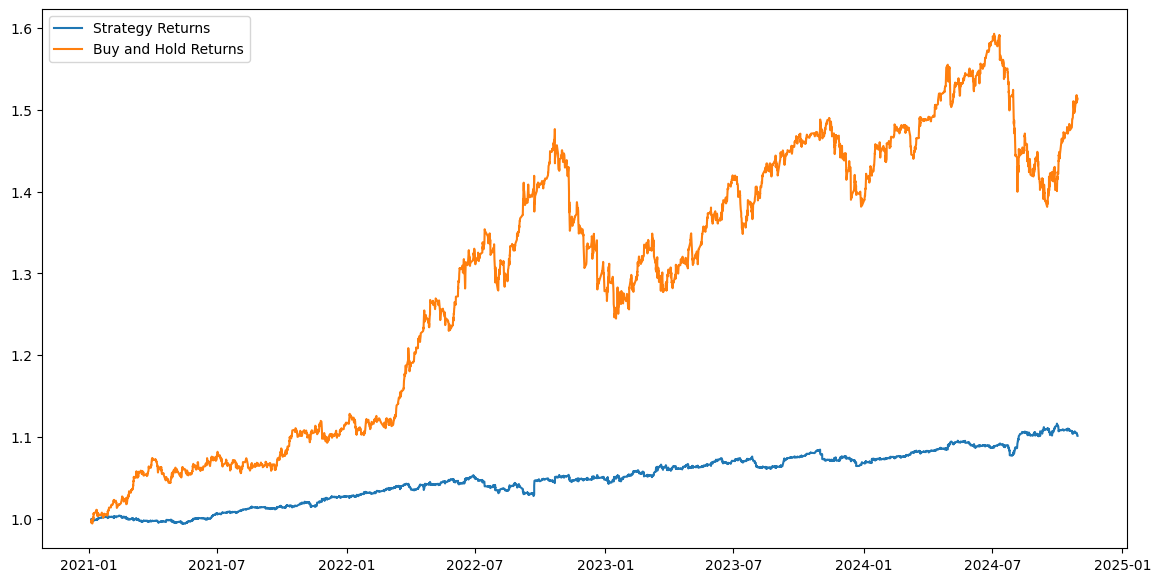

In [16]:
# strategy
df_filtered['pred'] = df_filtered['pred'].map({0: -1, 1: 1})
df_filtered['strategy'] = df_filtered['pred'] * df_filtered['s_returns']
df_filtered['cumulative_strategy_returns'] = df_filtered["strategy"].cumsum().apply(np.exp)

# plot
plt.figure(figsize=(14,7))
plt.plot(df_filtered['cumulative_strategy_returns'], label=f'Strategy Returns')
plt.plot(df_filtered['cumulative_buy_and_hold_returns'], label=f'Buy and Hold Returns')
plt.legend()
plt.show()

In [17]:
# Actual returns associated with each trade
annualized_factor = 24960  # The number of 15-minute bars in a year
annualized_sreturn = np.mean(df_filtered['strategy']) * annualized_factor
print(f"Annualized Strategy Return: {annualized_sreturn:.2f}")

# Sharpe Ratio
risk_free_rate = 0  # Assuming risk-free rate is 0 for simplicity
mean_return = np.mean(df_filtered['strategy']) * annualized_factor
std_return = np.std(df_filtered['strategy']) * np.sqrt(annualized_factor)
sharpe_ratio = (mean_return - risk_free_rate) / std_return
print(f"Annualized Sharpe Ratio: {sharpe_ratio:.2f}")


# Maximum Drawdown
def max_drawdown(strategy_returns):
    cumulative = np.cumsum(strategy_returns)
    drawdown = cumulative - np.maximum.accumulate(cumulative)
    return np.min(drawdown)

max_dd = max_drawdown(df_filtered['strategy'])
print(f"Maximum Drawdown: {max_dd:.2f}")

Annualized Strategy Return: 0.45
Annualized Sharpe Ratio: 4.92
Maximum Drawdown: -0.02


In [18]:
# Calculate wins and losses, treating losses as positive values
df_filtered['loss'] = np.where(df_filtered['strategy'] < 0, abs(df_filtered['strategy']), np.nan)
df_filtered['win'] = np.where(df_filtered['strategy'] > 0, df_filtered['strategy'], np.nan)

# Calculate the average win-to-loss ratio
win_loss_ratio = df_filtered['win'].mean() / df_filtered['loss'].mean()

# Handle cases where loss is zero or NaN
win_loss_ratio = np.where(np.isnan(win_loss_ratio) | (win_loss_ratio == 0), 1, win_loss_ratio)

# Calculate the Kelly Criterion using the improved formula
df_filtered['kelly'] = (df_filtered['prob'] - (1 - df_filtered['prob']) / win_loss_ratio)
win_loss_ratio

array(0.98549376)

In [19]:
df_filtered.describe()

,Open,High,Low,Close,returns,target,s_returns,cumulative_buy_and_hold_returns,volatility,returns_div_volatility,...,hmm_prob_4,pred,prob_class_-1,prob_class_1,prob,strategy,cumulative_strategy_returns,loss,win,kelly
count,5404.000000,5404.000000,5404.000000,5404.000000,5404.000000,5404.000000,5404.000000,5404.000000,5404.000000,5404.000000,...,5.404000e+03,5404.000000,5404.000000,5404.000000,5404.000000,5404.000000,5404.000000,2522.000000,2826.000000,5404.000000
mean,132.753217,132.806717,132.708133,132.761086,0.000058,0.493893,0.000009,1.297074,0.000443,0.196347,...,4.538042e-02,-0.469282,0.504566,0.495434,0.515350,0.000018,1.050217,0.000367,0.000362,0.023566
std,16.827720,16.839289,16.817717,16.829687,0.000522,0.500009,0.000575,0.171149,0.000453,0.996305,...,2.015442e-01,0.883130,0.018498,0.018498,0.011285,0.000575,0.031794,0.000423,0.000470,0.022736
min,102.651000,102.667000,102.597000,102.629000,-0.006589,0.000000,-0.010723,0.994292,0.000039,-3.248917,...,4.911037e-15,-1.000000,0.432447,0.423844,0.500001,-0.004815,0.993963,0.000006,0.000006,-0.007358
25%,114.100750,114.130250,114.079000,114.085250,-0.000103,0.000000,-0.000221,1.107185,0.000219,-0.370183,...,8.920139e-10,-1.000000,0.498735,0.481321,0.506314,-0.000210,1.026623,0.000097,0.000102,0.005362
50%,136.100000,136.181000,136.042000,136.129500,0.000055,0.000000,0.000000,1.327621,0.000339,0.169342,...,8.045543e-08,-1.000000,0.507788,0.492212,0.513699,0.000020,1.050577,0.000232,0.000235,0.020240
75%,147.362000,147.402250,147.322500,147.361500,0.000254,1.000000,0.000239,1.445376,0.000529,0.776220,...,1.845666e-05,1.000000,0.518679,0.501265,0.521967,0.000248,1.074558,0.000482,0.000465,0.036898
max,161.934000,161.943000,161.909000,161.934000,0.003738,1.000000,0.005181,1.592926,0.010126,3.242343,...,1.000000e+00,1.000000,0.576156,0.567553,0.576156,0.010723,1.116375,0.004815,0.010723,0.146073


In [20]:
df

,Open,High,Low,Close,returns,target,s_returns,cumulative_buy_and_hold_returns,volatility,returns_div_volatility,...,hmm_prob_4,pred,prob_class_-1,prob_class_1,prob,strategy,cumulative_strategy_returns,loss,win,kelly
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-04 04:30:00,103.048,103.055,103.000,103.009,-0.000378,0,-0.000184,0.997783,0.000336,-1.125560,...,0.000000e+00,1,0.474983,0.525017,0.525017,-0.000184,0.999816,0.000184,NaN,0.035926
2021-01-04 04:45:00,103.009,103.026,102.990,102.990,-0.000184,0,-0.000175,0.997608,0.000271,-0.680213,...,1.933468e-09,1,0.486209,0.513791,0.513791,-0.000175,0.999641,0.000175,NaN,0.013141
2021-01-04 05:00:00,102.990,103.003,102.959,102.972,-0.000175,1,0.000146,0.997754,0.000259,-0.675137,...,1.252986e-09,1,0.482193,0.517807,0.517807,0.000146,0.999786,NaN,0.000146,0.021291
2021-01-04 05:15:00,102.972,102.998,102.961,102.987,0.000146,0,-0.000117,0.997638,0.000250,0.583138,...,3.852380e-11,-1,0.518366,0.481634,0.518366,0.000117,0.999903,NaN,0.000117,0.022426
2021-01-04 05:30:00,102.988,102.989,102.967,102.975,-0.000117,0,-0.000418,0.997221,0.000182,-0.641634,...,6.776394e-11,1,0.496748,0.503252,0.503252,-0.000418,0.999486,0.000418,NaN,-0.008251
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-10-29 22:45:00,153.368,153.380,153.323,153.325,-0.000293,1,0.000111,1.513059,0.000204,-1.438229,...,7.812079e-12,1,0.465822,0.534178,0.534178,0.000111,3.079514,NaN,0.000111,0.054520
2024-10-29 23:15:00,153.327,153.356,153.318,153.342,0.000111,0,-0.000007,1.513049,0.000199,0.558407,...,1.308614e-13,-1,0.520395,0.479605,0.520395,0.000007,3.079534,NaN,0.000007,0.026545
2024-10-29 23:30:00,153.395,153.395,153.321,153.341,-0.000007,1,0.000085,1.513177,0.000148,-0.044102,...,5.601111e-12,-1,0.513356,0.486644,0.513356,-0.000085,3.079273,0.000085,NaN,0.012259


In [21]:
df_filtered_2 = df_filtered[(df_filtered['kelly'] > 0)].copy()
df_filtered_2['pred'] = df_filtered_2['pred'].map({-1: 0, 1: 1})
accuracy = accuracy_score(df_filtered_2.target, df_filtered_2.pred) * 100
accuracy

53.352322524101666

In [22]:
df_filtered_2

,Open,High,Low,Close,returns,target,s_returns,cumulative_buy_and_hold_returns,volatility,returns_div_volatility,...,hmm_prob_4,pred,prob_class_-1,prob_class_1,prob,strategy,cumulative_strategy_returns,loss,win,kelly
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-04 05:45:00,102.975,102.984,102.931,102.932,-0.000418,1,0.000068,0.997289,0.000184,-2.274328,...,1.080209e-10,1,0.443548,0.556452,0.556452,0.000068,0.999650,NaN,0.000068,0.106375
2021-01-04 11:15:00,102.795,102.805,102.757,102.784,-0.000107,0,-0.000389,0.995401,0.000357,-0.299784,...,4.416813e-09,1,0.496048,0.503952,0.503952,-0.000389,0.999262,0.000389,NaN,0.000603
2021-01-04 11:30:00,102.784,102.786,102.725,102.744,-0.000389,0,-0.000282,0.995120,0.000351,-1.108503,...,6.229762e-09,1,0.461495,0.538505,0.538505,-0.000282,0.998980,0.000282,NaN,0.070217
2021-01-04 14:45:00,102.858,102.927,102.852,102.893,0.000340,1,0.000097,0.996942,0.000213,1.597094,...,1.039262e-09,0,0.524460,0.475540,0.524460,-0.000097,0.998882,0.000097,NaN,0.041920
2021-01-04 16:00:00,102.955,103.048,102.934,103.018,0.000622,0,-0.000165,0.997891,0.000351,1.768563,...,2.416463e-08,0,0.521767,0.478233,0.521767,0.000165,0.999047,NaN,0.000165,0.036495
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-10-28 11:45:00,153.092,153.097,152.967,153.042,-0.000327,0,-0.000778,1.508895,0.000368,-0.886376,...,5.682601e-06,1,0.476459,0.523541,0.523541,-0.000778,1.103839,0.000778,NaN,0.040069
2024-10-28 17:30:00,152.919,152.992,152.909,152.980,0.000399,1,0.000497,1.510214,0.000574,0.694603,...,4.150538e-06,0,0.506727,0.493273,0.506727,-0.000497,1.103291,0.000497,NaN,0.006193
2024-10-28 19:45:00,153.228,153.299,153.215,153.274,0.000300,0,-0.000033,1.512316,0.000364,0.825607,...,1.273993e-10,0,0.505824,0.494176,0.505824,0.000033,1.103003,NaN,0.000033,0.004374


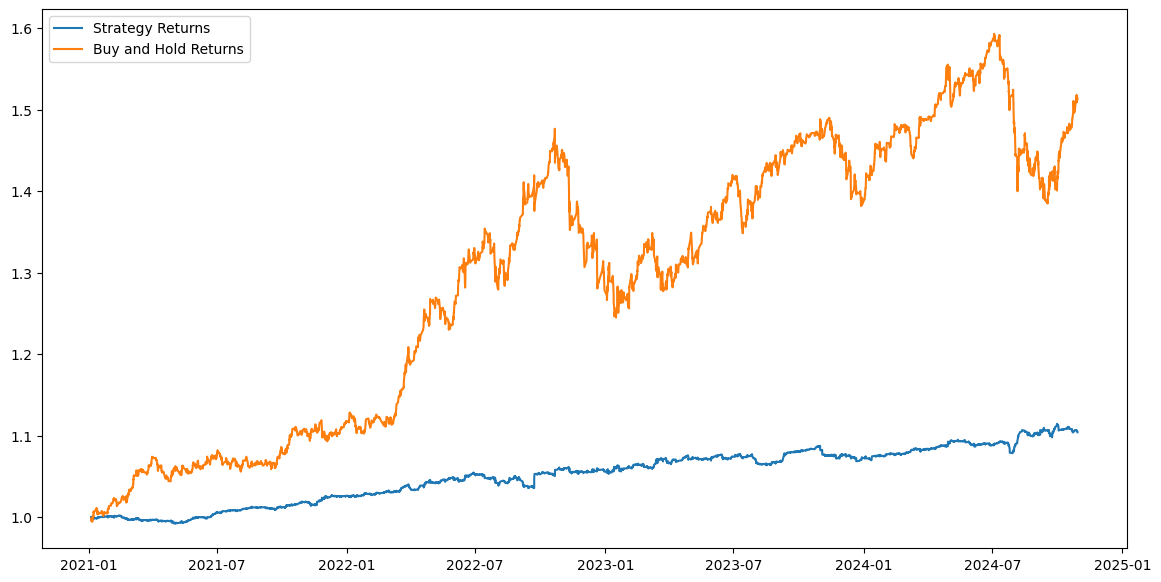

In [23]:
# strategy
df_filtered_2['pred'] = df_filtered_2['pred'].map({0: -1, 1: 1})
df_filtered_2['strategy'] = df_filtered_2['pred'] * df_filtered_2['s_returns']
df_filtered_2['cumulative_strategy_returns'] = df_filtered_2["strategy"].cumsum().apply(np.exp)

# plot
plt.figure(figsize=(14,7))
plt.plot(df_filtered_2['cumulative_strategy_returns'], label=f'Strategy Returns')
plt.plot(df_filtered_2['cumulative_buy_and_hold_returns'], label=f'Buy and Hold Returns')
plt.legend()
plt.show()

In [25]:
# Calculate wins and losses, treating losses as positive values
df_filtered_2['loss'] = np.where(df_filtered_2['strategy'] < 0, abs(df_filtered_2['strategy']), np.nan)
df_filtered_2['win'] = np.where(df_filtered_2['strategy'] > 0, df_filtered_2['strategy'], np.nan)

# Calculate the average win-to-loss ratio
win_loss_ratio = df_filtered_2['win'].mean() / df_filtered_2['loss'].mean()

# Handle cases where loss is zero or NaN
win_loss_ratio = np.where(np.isnan(win_loss_ratio) | (win_loss_ratio == 0), 1, win_loss_ratio)

# Calculate the Kelly Criterion using the improved formula
df_filtered['kelly'] = (df_filtered_2['prob'] - (1 - df_filtered_2['prob']) / win_loss_ratio)
win_loss_ratio

array(0.99926467)

In [24]:
# Actual returns associated with each trade
annualized_factor = 24960  # The number of 15-minute bars in a year
annualized_sreturn = np.mean(df_filtered_2['strategy']) * annualized_factor
print(f"Annualized Strategy Return: {annualized_sreturn:.2f}")

# Sharpe Ratio
risk_free_rate = 0  # Assuming risk-free rate is 0 for simplicity
mean_return = np.mean(df_filtered_2['strategy']) * annualized_factor
std_return = np.std(df_filtered_2['strategy']) * np.sqrt(annualized_factor)
sharpe_ratio = (mean_return - risk_free_rate) / std_return
print(f"Annualized Sharpe Ratio: {sharpe_ratio:.2f}")


# Maximum Drawdown
def max_drawdown(strategy_returns):
    cumulative = np.cumsum(strategy_returns)
    drawdown = cumulative - np.maximum.accumulate(cumulative)
    return np.min(drawdown)

max_dd = max_drawdown(df_filtered_2['strategy'])
print(f"Maximum Drawdown: {max_dd:.2f}")

Annualized Strategy Return: 0.54
Annualized Sharpe Ratio: 5.83
Maximum Drawdown: -0.02
